# GRAD CAM 

In [2]:
import os
import pandas as pd

data_path = "/kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset/OS Collected Data"

images = []
labels = []

for subfolder in os.listdir(data_path):

    subfolder_path = os.path.join(data_path, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for image_filename in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, image_filename)
        images.append(image_path)

        labels.append(subfolder)

data = pd.DataFrame({'image': images, 'label': labels})

In [3]:
data.to_csv("/kaggle/working/Osteoporosis.csv")

In [4]:
df = pd.read_csv("/kaggle/working/Osteoporosis.csv")
df

,Unnamed: 0,image,label
0,0,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
1,1,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
2,2,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
3,3,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
4,4,/kaggle/input/multi-class-knee-osteoporosis-x-...,Osteopenia
...,...,...,...
1942,1942,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1943,1943,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1944,1944,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal
1945,1945,/kaggle/input/multi-class-knee-osteoporosis-x-...,Normal


In [5]:
df['label'].value_counts()

label
Osteoporosis    793
Normal          780
Osteopenia      374
Name: count, dtype: int64

In [6]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Input

# Load CSV file
csv_path = "/kaggle/working/Osteoporosis.csv"
df = pd.read_csv(csv_path)

# Encode labels
label_mapping = {label: idx for idx, label in enumerate(df['label'].unique())}
df['label'] = df['label'].map(label_mapping)

# Load and augment images using Pillow
def load_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB').resize(target_size)
    img = img_to_array(img) / 255.0  # Normalize
    img = np.expand_dims(img, axis=-1)  # Add channel dimension (H, W) → (H, W, 1)
    return img

image_paths = df['image'].values
labels = df['label'].values

# Split dataset (80% training, 20% validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(image_paths, labels, test_size=0.2, stratify=labels)

## Transfer Learning Models Grad CAM

Generating Grad-CAM for DenseNet121...


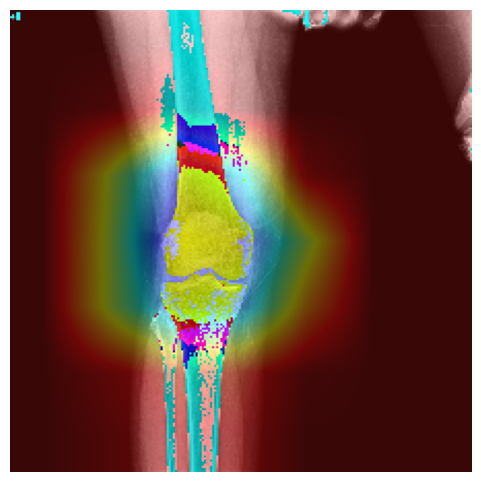

Generating Grad-CAM for InceptionV3...


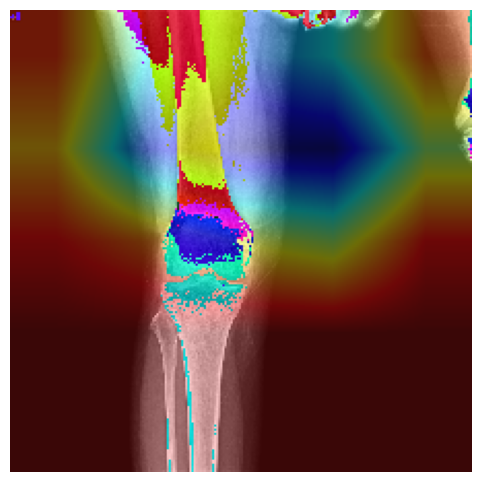

Generating Grad-CAM for ResNet50...


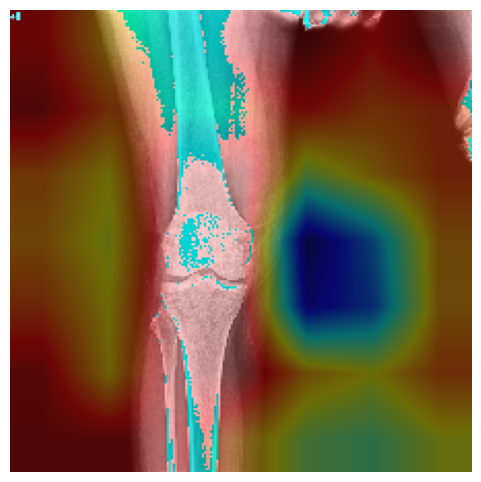

Generating Grad-CAM for VGG16...


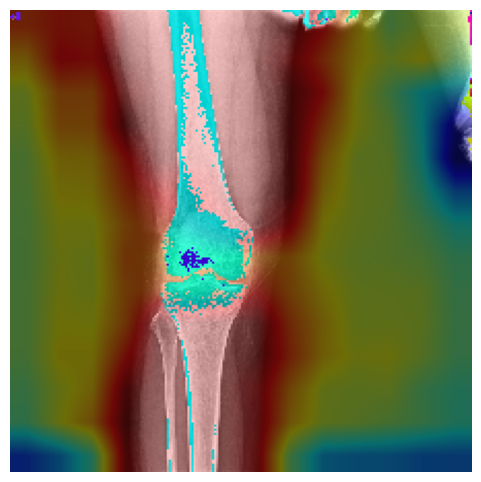

Generating Grad-CAM for VGG19...


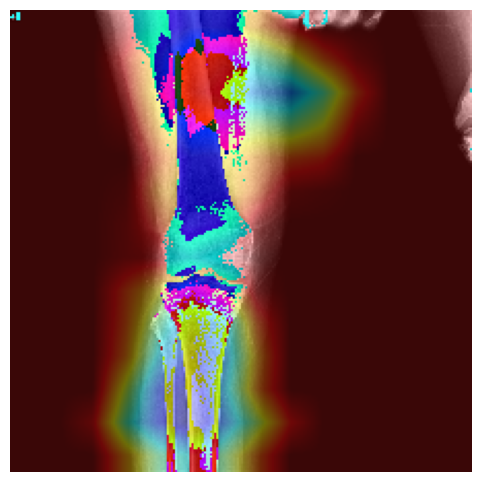

Generating Grad-CAM for Xception...


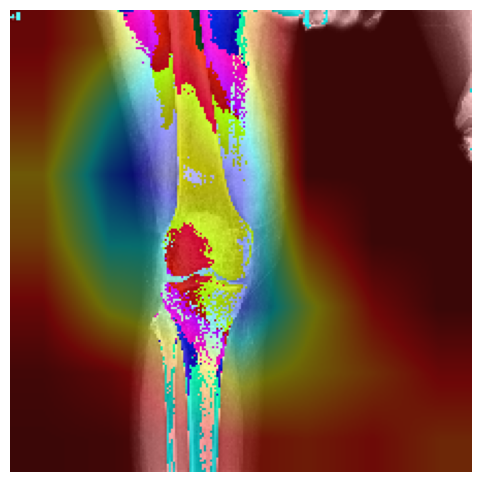

Generating Grad-CAM for late_fusion_vgg_inception...


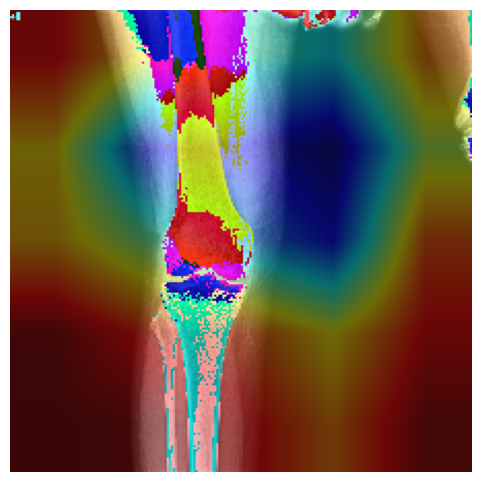

Generating Grad-CAM for Custom CNN...


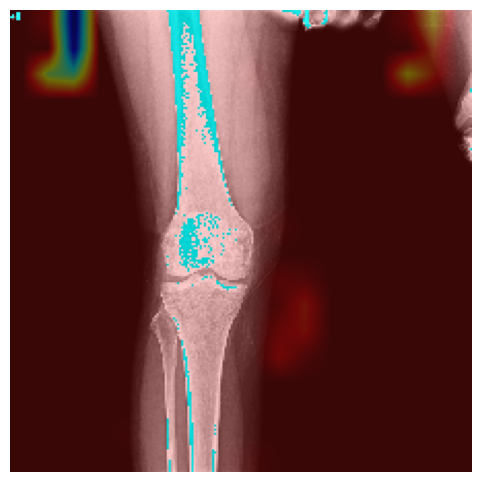

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import cv2

def load_image(image_path):
    img = load_img(image_path, color_mode='grayscale', target_size=(224, 224))
    img_array = img_to_array(img)  # shape: (224, 224, 1)
    return img_array / 255.0  # Normalize

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(image_path, model, last_conv_layer_name='block5_conv3'):
    img = load_image(image_path)  # Grayscale (224, 224, 1)
    img_rgb = np.repeat(img, 3, axis=-1)  # Convert grayscale to 3 channels
    img_array = np.expand_dims(img_rgb, axis=0)  # Add batch dimension

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * 0.4 + (img_rgb * 255).astype(np.uint8)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.axis('off')
    plt.show()

# Models and config
models_info = {
    # 'AlexNet': {'model_path': '/kaggle/input/osteoporosis-models/keras/default/1/AlexNet_knee_osteo_model.keras', 'last_conv_layer_name': 'conv2d_106'},
    'DenseNet121': {'model_path': '/kaggle/input/models/keras/default/6/DenseNet121_osteo_model.keras', 'last_conv_layer_name': 'conv5_block16_2_conv'},
    'InceptionV3': {'model_path': '/kaggle/input/models/keras/default/6/InceptionV3_knee_osteo_model.keras', 'last_conv_layer_name': 'mixed10'},
    'ResNet50': {'model_path': '/kaggle/input/models/keras/default/6/ResNet50_knee_osteo_model.keras', 'last_conv_layer_name': 'conv5_block3_out'},
    'VGG16': {'model_path': '/kaggle/input/models/keras/default/6/VGG16_knee_osteo_model.keras', 'last_conv_layer_name': 'block5_conv3'},
    'VGG19': {'model_path': '/kaggle/input/models/keras/default/6/VGG19_knee_osteo_model.keras', 'last_conv_layer_name': 'block5_conv4'},
    'Xception': {'model_path': '/kaggle/input/models/keras/default/6/Xception_knee_osteo_model.keras', 'last_conv_layer_name': 'block14_sepconv2_act'},
    'late_fusion_vgg_inception': {'model_path': '/kaggle/input/models/keras/default/6/late_fusion_vgg_inception.keras', 'last_conv_layer_name': 'mixed10'},
    'Custom CNN': {'model_path': '//kaggle/input/models/keras/default/6/CustomCNN_3_knee_osteo_model.keras', 'last_conv_layer_name': 'conv2d_7'}
}

sample_image_path = "/kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset/OS Collected Data/Osteopenia/Osteopenia 1.jpg"

for model_name, model_info in models_info.items():
    print(f"Generating Grad-CAM for {model_name}...")
    model = tf.keras.models.load_model(model_info['model_path'])
    display_gradcam(sample_image_path, model, last_conv_layer_name=model_info['last_conv_layer_name'])

Generating Grad-CAM for MobileNetV2...


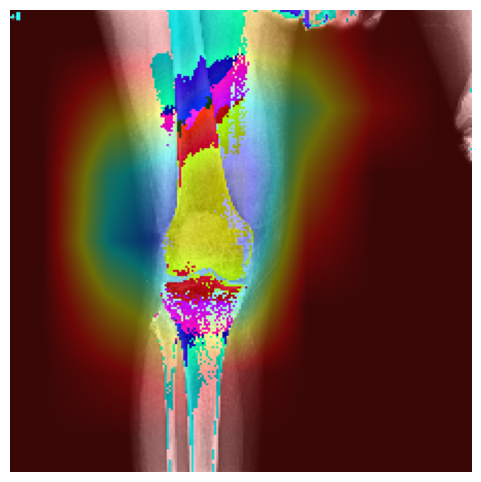

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
import cv2

def load_image(image_path):
    img = load_img(image_path, color_mode='grayscale', target_size=(224, 224))
    img_array = img_to_array(img)  # shape: (224, 224, 1)
    return img_array / 255.0  # Normalize

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(image_path, model, last_conv_layer_name='block5_conv3'):
    img = load_image(image_path)  # Grayscale (224, 224, 1)
    img_rgb = np.repeat(img, 3, axis=-1)  # Convert grayscale to 3 channels
    img_array = np.expand_dims(img_rgb, axis=0)  # Add batch dimension

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * 0.4 + (img_rgb * 255).astype(np.uint8)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.axis('off')
    plt.show()

# Models and config
models_info = {
    'MobileNetV2': {'model_path': '/kaggle/input/models/keras/default/6/MobileNetV2_knee_osteo_model.keras', 'last_conv_layer_name': 'Conv_1_bn'}
}

sample_image_path = "/kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset/OS Collected Data/Osteopenia/Osteopenia 1.jpg"

for model_name, model_info in models_info.items():
    print(f"Generating Grad-CAM for {model_name}...")
    model = tf.keras.models.load_model(model_info['model_path'])
    display_gradcam(sample_image_path, model, last_conv_layer_name=model_info['last_conv_layer_name'])

## Ensemble Models Grad CAM

In [22]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dictionary of model paths and last conv layer names
models_info = {
    'DenseNet121': {'model_path': '/kaggle/input/models/keras/default/6/DenseNet121_osteo_model.keras', 'last_conv_layer_name': 'conv5_block16_2_conv'},
    'InceptionV3': {'model_path': '/kaggle/input/models/keras/default/6/InceptionV3_knee_osteo_model.keras', 'last_conv_layer_name': 'mixed10'},
    'ResNet50': {'model_path': '/kaggle/input/models/keras/default/6/ResNet50_knee_osteo_model.keras', 'last_conv_layer_name': 'conv5_block3_out'},
    'VGG16': {'model_path': '/kaggle/input/models/keras/default/6/VGG16_knee_osteo_model.keras', 'last_conv_layer_name': 'block5_conv3'},
    'VGG19': {'model_path': '/kaggle/input/models/keras/default/6/VGG19_knee_osteo_model.keras', 'last_conv_layer_name': 'block5_conv4'},
    'Xception': {'model_path': '/kaggle/input/models/keras/default/6/Xception_knee_osteo_model.keras', 'last_conv_layer_name': 'block14_sepconv2_act'},
    'MobileNetV2': {'model_path': '/kaggle/input/models/keras/default/6/MobileNetV2_knee_osteo_model.keras', 'last_conv_layer_name': 'Conv_1_bn'},
    'Custom CNN': {'model_path': '/kaggle/input/models/keras/default/6/CustomCNN_3_knee_osteo_model.keras', 'last_conv_layer_name': 'conv2d_7'}
}

# Load and preprocess image
def load_preprocess_image(img_path, target_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    return img_array, np.array(img) / 255.0

# Grad-CAM function
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Overlay heatmap
def overlay_heatmap(heatmap, image, alpha=0.4):
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    superimposed_img = heatmap_color * alpha + image * 255
    return np.uint8(superimposed_img)

# Main function to run ensemble Grad-CAM
def gradcam_ensemble_pair(model_name1, model_name2, image_path):
    model_info1 = models_info[model_name1]
    model_info2 = models_info[model_name2]

    model1 = tf.keras.models.load_model(model_info1['model_path'])
    model2 = tf.keras.models.load_model(model_info2['model_path'])

    last_layer1 = model_info1['last_conv_layer_name']
    last_layer2 = model_info2['last_conv_layer_name']

    img_array, original_img = load_preprocess_image(image_path)

    heatmap1 = get_gradcam_heatmap(model1, img_array, last_layer1)
    heatmap2 = get_gradcam_heatmap(model2, img_array, last_layer2)

    # Resize heatmaps to the same size before averaging
    heatmap1_resized = cv2.resize(heatmap1, (224, 224))
    heatmap2_resized = cv2.resize(heatmap2, (224, 224))

    final_heatmap = np.mean([heatmap1_resized, heatmap2_resized], axis=0)
    final_image = overlay_heatmap(final_heatmap, original_img)

    plt.figure(figsize=(10, 5))
    plt.imshow(final_image)
    plt.title(f"Ensemble Grad-CAM: {model_name1} + {model_name2}")
    plt.axis('off')
    plt.show()

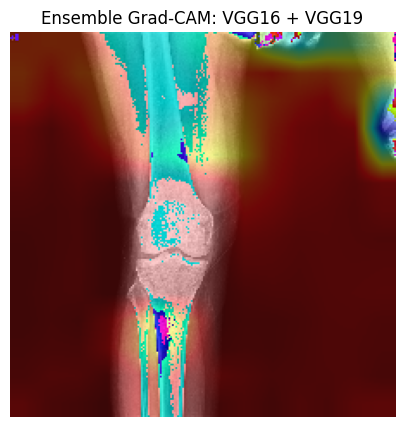

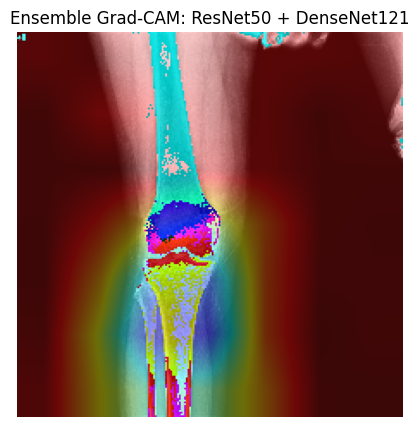

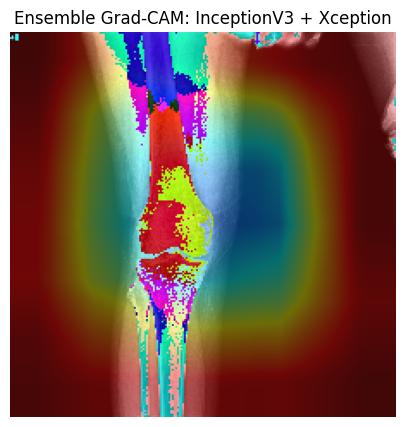

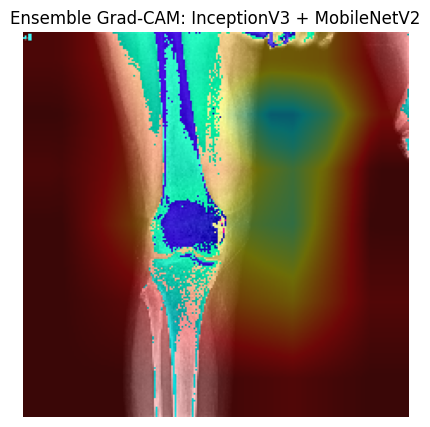

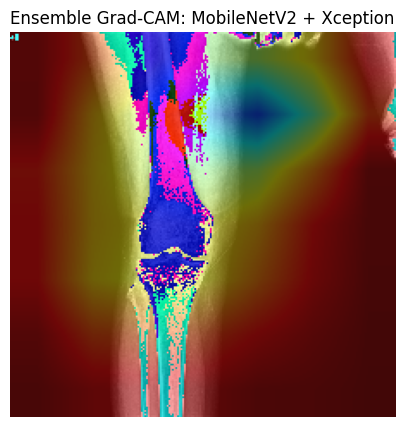

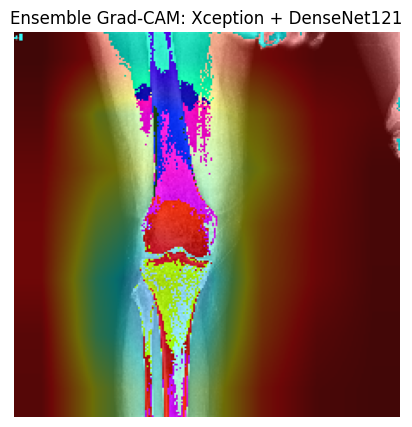

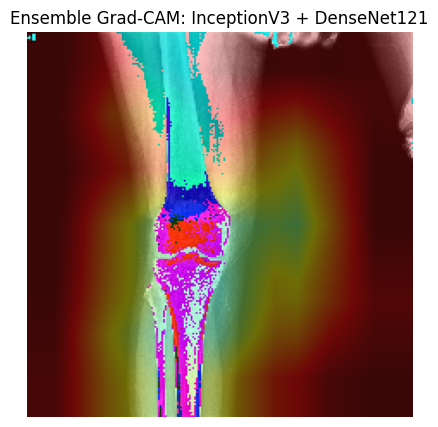

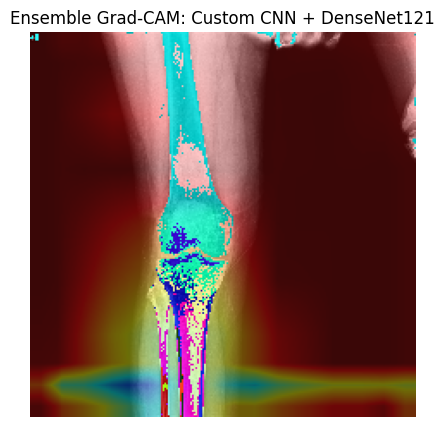

In [23]:
sample_image_path = "/kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset/OS Collected Data/Osteopenia/Osteopenia 1.jpg"

pairs = [
    ("VGG16", "VGG19"),
    ("ResNet50", "DenseNet121"),
    ("InceptionV3", "Xception"),
    ("InceptionV3", "MobileNetV2"),
    ("MobileNetV2", "Xception"),
    ("Xception", "DenseNet121"),
    ("InceptionV3", "DenseNet121"),
    ("Custom CNN", "DenseNet121")
]

for model1, model2 in pairs:
    gradcam_ensemble_pair(model1, model2, sample_image_path)